## Desarrollo:
* Exploración: Identificar el número de clases, el balanceo de las mismas y la resolución de las imágenes.
* Generador de Datos: Implementar una clase Sequence de Keras.
* Diseño del modelo: Puedes optar por arquitecturas propias o utilizar arquitecturas conocidas y adaptarlas a este conjunto de datos. Es obligatorio el uso de callbacks como EarlyStopping y ModelCheckpoint (y livelossplot).
* Evaluación:  Deberás generar un archivo subm.csv siguiendo la plantilla proporcionada para subirlo a la plataforma.

##  Importaciones

In [1]:
import os
try:
    from google.colab import drive
    COLAB = True
    print("Estoy en Google CoLab")
    %tensorflow_version 2.x
    !pip install livelossplot

    try:
      from google.colab import drive
      drive.mount('/content/drive')

      # Ruta en tu Drive donde guardarás el dataset
      DRIVE_DATA_DIR = "/content/drive/MyDrive/TheBestCourseOfDLIveNeverTaken/datasets"
      DRIVE_MODEL_DIR = "/content/drive/MyDrive/TheBestCourseOfDLIveNeverTaken/models"
      os.makedirs(DRIVE_DATA_DIR, exist_ok=True)
      os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)

      DRIVE = True
    except:
      DRIVE = False



except:
    os.environ["CUDA_VISIBLE_DEVICES"]="0"
    print("No estoy en Google CoLab")
    COLAB = False
    DRIVE = False

COLAB

No estoy en Google CoLab


False

In [2]:
import os
import random
import zipfile
import shutil
import urllib.request


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


import tensorflow as tf
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation, BatchNormalization, Add, GlobalAveragePooling2D, GlobalMaxPooling2D, concatenate, DepthwiseConv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2


from livelossplot import PlotLossesKeras
from collections import Counter
import keras_tuner as kt 

##  Descarga de los datos

La siguiente celda descarga los datos y descomprime el archivo. El directorio donde se encuentra los datos se guarda en la variable *dataset_dir*:

In [3]:
# URL del dataset
DATASET_URL = "https://hdvirtual.us.es/discovirt/public.php/dav/files/ssQnAor7wgoRFN8"


if DRIVE:

    ZIP_PATH = os.path.join(DRIVE_DATA_DIR, "FacialExpressionDS.zip")
    DATASET_DIR = ZIP_PATH.replace(".zip", "")

    # Solo descarga si no existe ya
    if not os.path.exists(DATASET_DIR):
        dataset_path = tf.keras.utils.get_file(
            "FacialExpressionDS.zip",
            origin=DATASET_URL,
            extract=False,
            cache_dir=DRIVE_DATA_DIR,
            cache_subdir=""
        )

    os.makedirs("Data", exist_ok=True)

    dataset_path = os.path.join("Data", "FacialExpressionDS.zip")

    if not os.path.exists(dataset_path):

      shutil.copy(os.path.join(DRIVE_DATA_DIR, "FacialExpressionDS.zip"),
              os.path.join(dataset_path))

      with zipfile.ZipFile(dataset_path, "r") as z:
        z.extractall("Data")

    print("Descargado y extraído en drive")

else:
    # Descargar y extraer
    dataset_path = tf.keras.utils.get_file(
        "FacialExpressionDS.zip",
        origin=DATASET_URL,
        extract=True
    )

# La función lo guarda en `~/.keras/datasets/` en local o donde se haya especificado en drive
dataset_dir = dataset_path.replace(".zip", "")  # Carpeta donde se extrajo
print(f"Directorio donde encoontrar los datos: {dataset_dir}")


Directorio donde encoontrar los datos: C:\Users\encis\.keras\datasets\FacialExpressionDS


##  Análisis del conjunto de datos

Descarga el conjunto de datos (la URL está en la DATASET_URL) y analiza la estructura del conjunto de datos. Necesitará determinar el número de clases y como se dividen los datos.


In [4]:
# Ver la estructura de carpetas
print("Contenido de dataset_dir:", os.listdir(dataset_dir))

Contenido de dataset_dir: ['data.yaml', 'test', 'train', 'valid']


In [5]:
# Bajar un nivel más
keras_datasets = os.path.join(os.path.expanduser("~"), ".keras", "datasets")
dataset_dir = os.path.join(keras_datasets, "FacialExpressionDS")

# Ahora inspecciona las clases reales
print("Clases encontradas:", os.listdir(dataset_dir))

Clases encontradas: ['data.yaml', 'test', 'train', 'valid']


In [6]:
# Ajusta según la salida anterior

print("Clases encontradas:", os.listdir(dataset_dir))

Clases encontradas: ['data.yaml', 'test', 'train', 'valid']


Obtenemos que tenemos 3 carpetas para la implementación del modelo: 
* Conjunto de entrenamiento en 'train', para entrenar los pesos de la red.
* Conjunto de validación en 'valid', para ajustar los hiperparametros de la red y medir rendimiento.
* Conjunto de 'test', para medir el rendimiento del modelo en Kaggle

Veamos las distintas clases para la clasificación

In [7]:
import yaml

yaml_path = os.path.join(dataset_dir, "data.yaml")

with open(yaml_path, "r") as f:
    config = yaml.safe_load(f)

clases = config["names"] # Lista de nombres de clases del data.yaml

print("Clases:", clases, f"\n Un total de {len(clases)} clases.")


Clases: ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise'] 
 Un total de 8 clases.


Veamos la distribución de cada clase en los conjuntos de entrenamiento y validación

In [8]:

for split in ["train", "valid"]:
    img_dir    = os.path.join(dataset_dir, split, "images")
    labels_dir = os.path.join(dataset_dir, split, "labels")
    
    n_imgs   = len(os.listdir(img_dir))    if os.path.exists(img_dir)    else 0
    n_labels = len(os.listdir(labels_dir)) if os.path.exists(labels_dir) else 0
    
    print(f"--- {split.upper()} ---")
    print(f"  Imágenes : {n_imgs}")
    print(f"  Etiquetas: {n_labels}")


--- TRAIN ---
  Imágenes : 17101
  Etiquetas: 17101
--- VALID ---
  Imágenes : 5406
  Etiquetas: 5406


In [9]:
def contar_clases(split):
    labels_dir = os.path.join(dataset_dir, split, "labels")
    conteo = Counter()
    
    if not os.path.exists(labels_dir):
        print(f"No existe: {labels_dir}")
        return conteo
    
    for archivo in os.listdir(labels_dir):
        if archivo.endswith(".txt"):
            with open(os.path.join(labels_dir, archivo), "r") as f:
                for linea in f:
                    linea = linea.strip()
                    if linea:
                        idx = int(linea.split()[0])  # primer valor = índice de clase
                        conteo[clases[idx]] += 1
    return conteo

# Contar por cada split
splits = ["train", "valid"]
data = {}
for split in splits:
    data[split] = contar_clases(split)

# Construir DataFrame
df = pd.DataFrame(data, index=clases).fillna(0).astype(int)

# Añadir totales y porcentajes
df["TOTAL"] = df.sum(axis=1)
for split in splits:
    df[f"{split}_%"] = (df[split] / df[split].sum() * 100).round(2)

print(df[["train", "valid", "TOTAL",
          "train_%", "valid_%"]])

          train  valid  TOTAL  train_%  valid_%
Anger      2339    712   3051    13.68    13.17
Contempt   1996    618   2614    11.67    11.43
Disgust    2242    672   2914    13.11    12.43
Fear       2021    622   2643    11.82    11.51
Happy      2154    791   2945    12.60    14.63
Neutral    1616    514   2130     9.45     9.51
Sad        1914    603   2517    11.19    11.15
Surprise   2819    874   3693    16.48    16.17


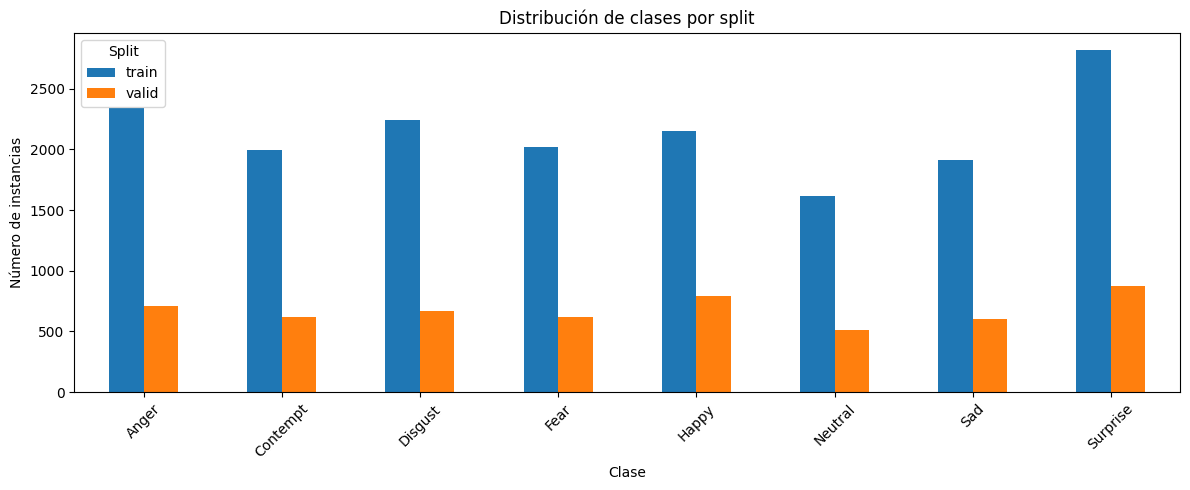

In [10]:
df[splits].plot(kind="bar", figsize=(12, 5))
plt.title("Distribución de clases por split")
plt.xlabel("Clase")
plt.ylabel("Número de instancias")
plt.xticks(rotation=45)
plt.legend(title="Split")
plt.tight_layout()
plt.show()

Observamos que no obtenemos una distribución uniforme de muestras para cada clase. Siendo las clases 'Surprise'/'Neutral' las más y menos poblada respectivamente.

In [11]:
clases_img = config["names"]
print(clases_img)

['Anger', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


In [12]:
from PIL import Image

img_dir = os.path.join(dataset_dir, "train", "images")
primera_img = os.path.join(img_dir, os.listdir(img_dir)[0])

img = Image.open(primera_img)
print("Dimensiones de la primera imagen conjunto de entrenamiento:", np.shape(img))

Dimensiones de la primera imagen conjunto de entrenamiento: (96, 96, 3)


Se tratan de imagenes de 96x96 en RGB

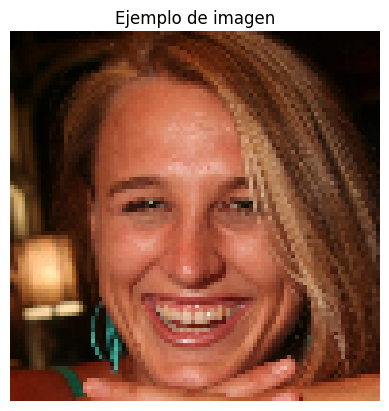

In [13]:
labels_dir = os.path.join(dataset_dir, "train", "labels")

nombre_label = os.path.splitext(primera_img)[0] + ".txt"
ruta_label   = os.path.join(labels_dir, nombre_label)

img = Image.open(primera_img)
plt.imshow(img)
plt.axis("off")
plt.title("Ejemplo de imagen")
plt.show()

In [14]:
labels_dir = os.path.join(dataset_dir, "train", "labels")

ruta_primera_img = os.path.join(labels_dir, os.listdir(labels_dir)[0])

# Leer el archivo de etiqueta
with open(ruta_primera_img, "r") as f:
    lineas = f.readlines()

for linea in lineas:
    partes = linea.strip().split()
    idx    = int(partes[0])
    clase  = clases_img[idx]
    x, y, w, h = partes[1:]
    print(f"  Clase: {clase} (idx={idx}) | bbox → x={x}, y={y}, w={w}, h={h}")

  Clase: Happy (idx=4) | bbox → x=0.499, y=0.499, w=0.999, h=0.999


La primera imagen tiene asociada la etiqueta 'Happy'. El resto del archivo es típico del formato YOLO, que indica un recuadro centrado en (x,y) con altura y anchura h/w (en este caso, toda la imagen)

Como nuestro problema es de clasificación, en principio podemos quedarnos tan solo con la etiqueta de clasificación.

##  Generador de datos

Implementa un generador de datos de Keras para poder inyectar las entradas y las salidas a la red.

Utilizando de base la clase Sequence de clase, adaptando con cambios para nuestro dataset (imagenes 98x98 formato png, jpg o jpeg)

In [15]:


class FacialExpressionSequence(tf.keras.utils.Sequence):

    def __init__(self, img_dir, labels_dir, class_names, 
                 batch_size=32, img_size=(98, 98), shuffle=True):
        self.img_dir     = img_dir
        self.labels_dir  = labels_dir
        self.class_names = class_names
        self.batch_size  = batch_size
        self.img_size    = img_size
        self.shuffle     = shuffle

        # Lista de todos los archivos de imagen
        self.imagenes = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.imagenes) / self.batch_size))

    def __getitem__(self, idx):
        batch_files = self.imagenes[idx * self.batch_size : (idx + 1) * self.batch_size]
        
        X, y = [], []
        for fname in batch_files:
            img = Image.open(os.path.join(self.img_dir, fname)).resize(self.img_size)
            X.append(np.array(img) / 255.0)

            txt = os.path.splitext(fname)[0] + ".txt"
            with open(os.path.join(self.labels_dir, txt)) as f:
                clase_idx = int(f.readline().split()[0])
            y.append(clase_idx)

        # Convertir a one-hot 
        y_onehot = to_categorical(y, num_classes=len(self.class_names))

        return np.array(X), y_onehot


    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.imagenes)




Calculamos 'train_gen' y 'valid_gen' como la secuencia de imagenes a partir del directorio train y valid para pasarsela más adelante al modelo.

In [16]:
train_gen = FacialExpressionSequence(
    img_dir     = os.path.join(dataset_dir, "train", "images"),
    labels_dir  = os.path.join(dataset_dir, "train", "labels"),
    class_names = clases_img,
    batch_size  = 64,
    img_size    = (98, 98)
)

valid_gen = FacialExpressionSequence(
    img_dir     = os.path.join(dataset_dir, "valid", "images"),
    labels_dir  = os.path.join(dataset_dir, "valid", "labels"),
    class_names = clases_img,
    batch_size  = 64,
    shuffle     = False  # No mezclar validación
)

## Clasificador de expresiones faciales

Desarolla y entrena una red neuronal para clasificar las expresiones faciales buscando al mejor generalización posible del modelo.

Para este ejercicio se usará el F1-Score de tu entrega para evaluar la calidad de tus predicciones sobre el test.

**Nota**: Si estás usando Colab, es buena idea guardar modelos en Drive para evitar que se pierdan. Puedes usar el directorio *DRIVE_MODEL_DIR* que ya debería estar creado.

Partimos como modelo báse el último modelo entregado en la tarea de capas convolucionales. Adaptando las entradas y salidas a nuestro nuevo conjunto de datos.

### Modelo Inception

Debido a que estoy trabajando en local y quiero usar mi GPU para el entrenamiento de modelos. He tenido que degradar la version de TensorFlow, y me he tenido que crear la clase personalziada de F1Score como sigue:

In [19]:


numero_clases = len(clases_img)

# He tenido que degradar la version de TF para usar GPU de mi PC. Eso ha hecho que tenga que definir la clase de la metrica F1-score
class F1Score(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.f1    = self.add_weight(name='f1',    initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_classes = tf.argmax(y_pred, axis=-1)
        y_true_classes = tf.argmax(y_true, axis=-1)
        f1_total = 0.0
        for c in range(self.num_classes):
            tp = tf.reduce_sum(tf.cast((y_true_classes == c) & (y_pred_classes == c), tf.float32))
            fp = tf.reduce_sum(tf.cast((y_true_classes != c) & (y_pred_classes == c), tf.float32))
            fn = tf.reduce_sum(tf.cast((y_true_classes == c) & (y_pred_classes != c), tf.float32))
            precision = tp / (tp + fp + 1e-7)
            recall    = tp / (tp + fn + 1e-7)
            f1_total += 2 * precision * recall / (precision + recall + 1e-7)
        self.f1.assign_add(f1_total / self.num_classes)
        self.count.assign_add(1.0)

    def result(self):
        return self.f1 / self.count

    def reset_states(self):
        self.f1.assign(0.0)
        self.count.assign(0.0)

    def get_config(self):
        config = super().get_config()
        config.update({'num_classes': self.num_classes})
        return config

    @classmethod #Me faltaba config de la antigua clase, he tenido que definirlo ahora para cargar el mejor modelo
    def from_config(cls, config):
        # Si el archivo antiguo no tiene num_classes, usamos numero_clases
        config.setdefault('num_classes', numero_clases)
        return cls(**config)

Modelo inception base.

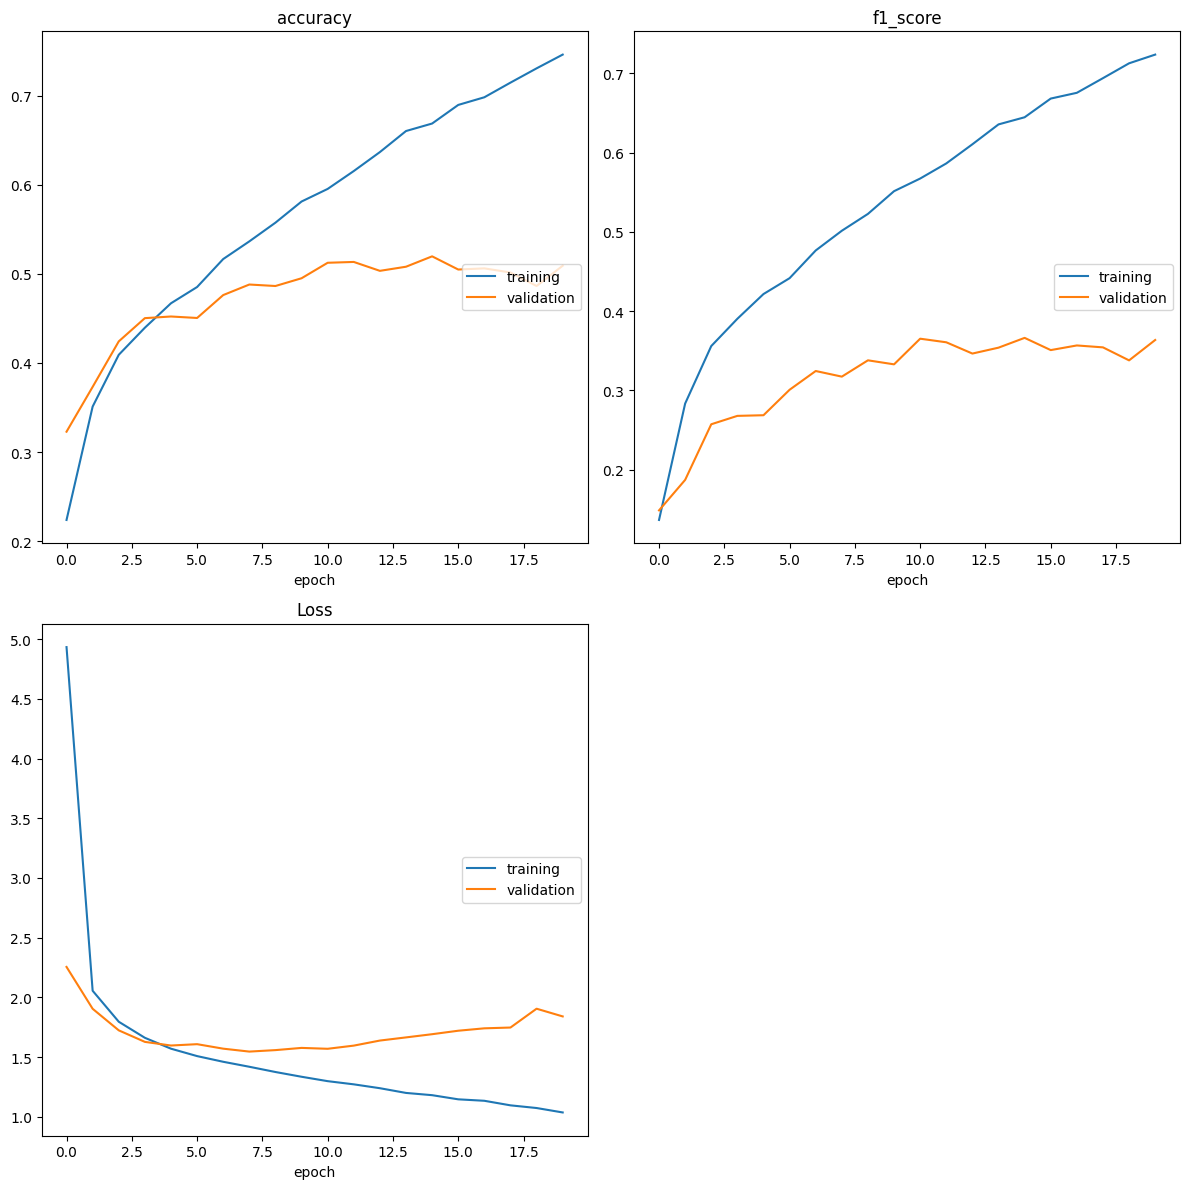

accuracy
	training         	 (min:    0.224, max:    0.746, cur:    0.746)
	validation       	 (min:    0.323, max:    0.520, cur:    0.509)
f1_score
	training         	 (min:    0.136, max:    0.724, cur:    0.724)
	validation       	 (min:    0.148, max:    0.366, cur:    0.364)
Loss
	training         	 (min:    1.036, max:    4.933, cur:    1.036)
	validation       	 (min:    1.546, max:    2.255, cur:    1.840)
268/268 [==============================] - 28s 104ms/step - loss: 1.0359 - accuracy: 0.7460 - f1_score: 0.7237 - val_loss: 1.8402 - val_accuracy: 0.5091 - val_f1_score: 0.3635


In [ ]:
def inception_block(x, filters_1x1=64, filters_3x3=64, filters_5x5=32, filters_pool=32):
    # Rama 1: 1x1
    branch1 = Conv2D(filters_1x1, (1,1), padding='same', activation='relu',
                     kernel_initializer='he_normal')(x)

    # Rama 2: 1x1 -> 3x3
    branch2 = Conv2D(filters_3x3, (1,1), padding='same', activation='relu',
                     kernel_initializer='he_normal')(x)
    branch2 = Conv2D(filters_3x3, (3,3), padding='same', activation='relu',
                     kernel_initializer='he_normal')(branch2)

    # Rama 3: 1x1 -> 5x5
    branch3 = Conv2D(filters_5x5, (1,1), padding='same', activation='relu',
                     kernel_initializer='he_normal')(x)
    branch3 = Conv2D(filters_5x5, (5,5), padding='same', activation='relu',
                     kernel_initializer='he_normal')(branch3)# Vimos en clase que tambien vale con aplicar 2 filtros 3x3

    # Rama 4: 3x3 max pool -> 1x1
    branch4 = MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    branch4 = Conv2D(filters_pool, (1,1), padding='same', activation='relu',
                     kernel_initializer='he_normal')(branch4)

    # Concatenar en canales
    x = concatenate([branch1, branch2, branch3, branch4], axis=-1)
    return x


inputs = tf.keras.Input(shape=(98, 98, 3))

# Convoluciones Inception
# Bloque 1 tipo Inception
x = inception_block(inputs, 32, 32, 16, 16)
x = MaxPooling2D((2,2))(x)

# Bloque 2 tipo Inception
x = inception_block(x, 64, 64, 32, 32)
x = MaxPooling2D((2,2))(x)

# Clasificador
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(256,
    kernel_initializer='he_normal',
    kernel_regularizer=tf.keras.regularizers.l2(0.002)
)(x)
x = tf.keras.layers.Activation('relu')(x)

outputs = tf.keras.layers.Dense(numero_clases, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)



model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        F1Score(num_classes=numero_clases, name='f1_score')  # ← clase personalizada
    ]
)

callbacks = [
    EarlyStopping(
        monitor='val_f1_score',   # Para cuando el F1 deje de mejorar
        patience=7,
        mode='max',               # F1 queremos que suba
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_f1_score',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    PlotLossesKeras()             # Gráfica en vivo dentro del notebook
]

model.fit(train_gen, validation_data=valid_gen, epochs=20, callbacks=callbacks )

Observamos que obtenemos unos valores de 'f1-score' bastante bajos en validación en comparación con el conjunto de entrenamiento (sobreajuste). Para tratar de mejorar el rendimiento aplicaremos los siguientes cambios:
* Aumentaremos dropout y bajaremos levemente penalización L2, para evitar tanto sobreajuste.
* Aplicamos 'BatchNormalization' para evitar altos valores en el gradiente y mejorar el aprendizaje. 'GlobalAveragePooling2D' en vez de flatten al modelo, evita tener tantos parámetros.
* En callbacks aplicamos 'ReduceLROnPlateau' para ir regulando el learning rate automaticamente, reduciendose durante las épocas.
* Penalizamos mediante class_weights por el desbalanceo entre clase, lo cual mejorara el rendimiento de 'f1-score' por la manera que se calcula.

In [ ]:
inputs = tf.keras.Input(shape=(98, 98, 3))

# Convoluciones Inception
# Bloque 1 tipo Inception
x = inception_block(inputs, 32, 32, 16, 16)
x = MaxPooling2D((2,2))(x)

# Bloque 2 tipo Inception
x = inception_block(x, 64, 64, 32, 32)
x = MaxPooling2D((2,2))(x)

# Convolucion con BatchNormalization
x = Conv2D(128, (3,3), padding='same', activation='relu',
           kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)

# Clasificador:
# En vez de Flatten Global Average
x = GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = Dense(256,
          kernel_initializer='he_normal',
          kernel_regularizer=tf.keras.regularizers.l2(0.0001))(x)
x = tf.keras.layers.Activation('relu')(x)

outputs = tf.keras.layers.Dense(numero_clases, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        F1Score(num_classes=numero_clases, name='f1_score')
    ]
)



Como hemos comentado antes, al tratarse de clases desbalanceadas vamos a aplicar un class_weight para ponderar en mayor medida el loss de las clases minoritarias para tratar que el modelo aprenda todas las clases por igual. Lo que debería mejorar el F1-Score.

In [20]:

from sklearn.utils import class_weight

labels_dir = os.path.join(dataset_dir, "train", "labels")

all_labels = []
for fname in os.listdir(labels_dir):
    if fname.endswith(".txt"):
        with open(os.path.join(labels_dir, fname), "r") as f:
            linea = f.readline().strip()
            if linea:
                clase_idx = int(linea.split()[0])
                all_labels.append(clase_idx)

print(f"Total muestras train: {len(all_labels)}")
print(f"Clases encontradas: {sorted(set(all_labels))}")

class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.arange(numero_clases),
    y=all_labels
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_array)}
print("Pesos por clase:")
for i, w in class_weights.items():
    print(f"  {clases_img[i]}: {w:.4f}")


Total muestras train: 17101
Clases encontradas: [0, 1, 2, 3, 4, 5, 6, 7]
Pesos por clase:
  Anger: 0.9139
  Contempt: 1.0710
  Disgust: 0.9534
  Fear: 1.0577
  Happy: 0.9924
  Neutral: 1.3228
  Sad: 1.1168
  Surprise: 0.7583


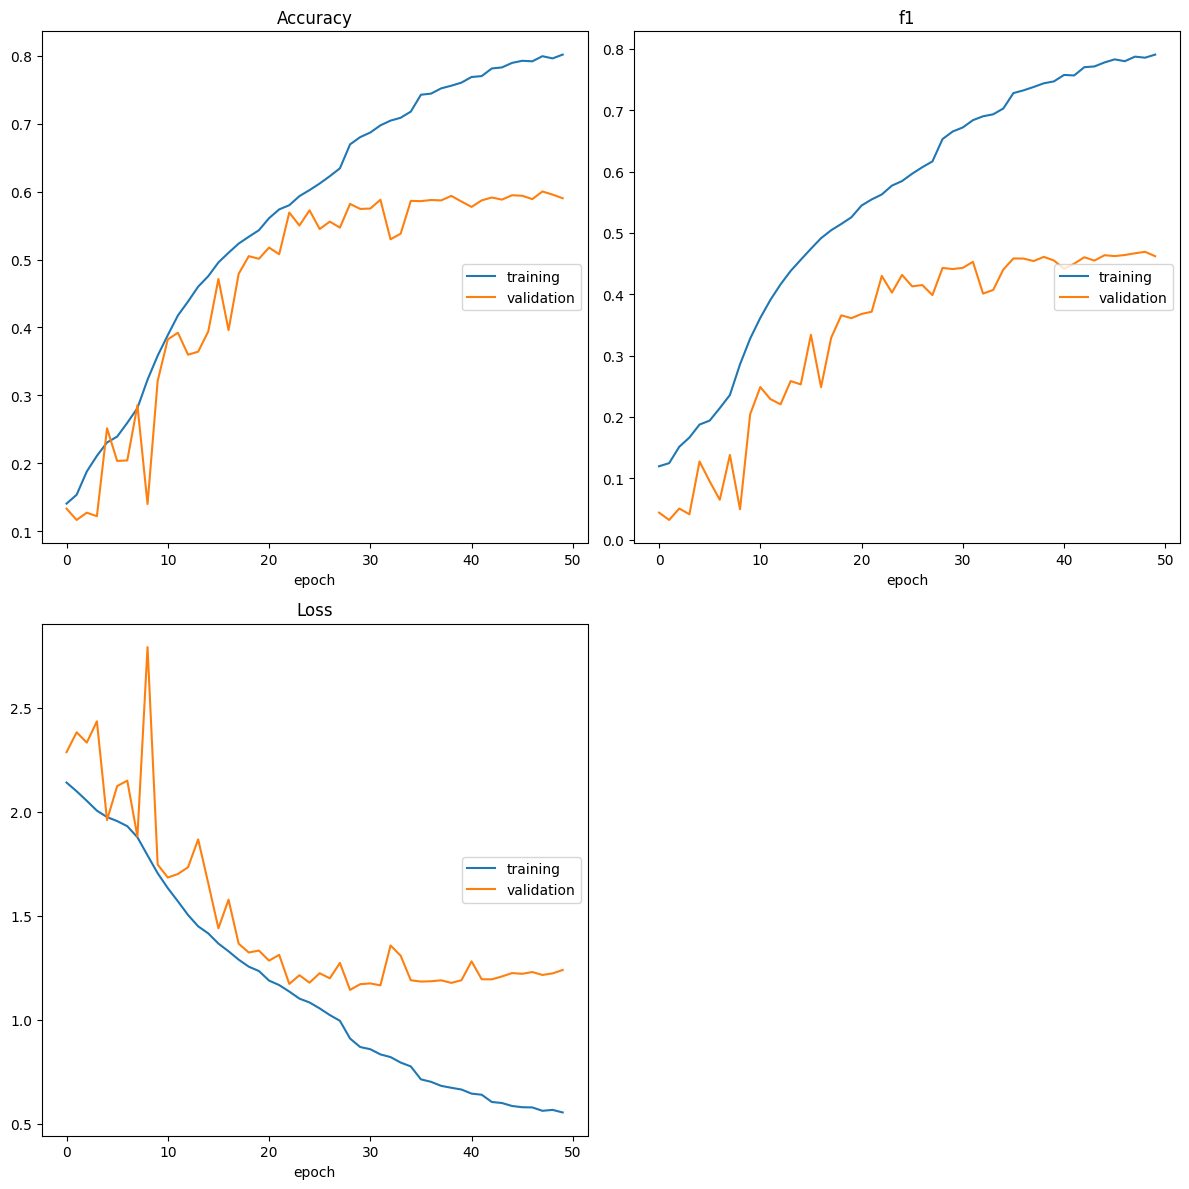

Accuracy
	training         	 (min:    0.140, max:    0.802, cur:    0.802)
	validation       	 (min:    0.116, max:    0.600, cur:    0.590)
f1
	training         	 (min:    0.120, max:    0.791, cur:    0.791)
	validation       	 (min:    0.032, max:    0.469, cur:    0.462)
Loss
	training         	 (min:    0.554, max:    2.141, cur:    0.554)
	validation       	 (min:    1.143, max:    2.792, cur:    1.239)
268/268 [==============================] - 27s 101ms/step - loss: 0.5537 - accuracy: 0.8019 - f1_score: 0.7908 - val_loss: 1.2390 - val_accuracy: 0.5903 - val_f1_score: 0.4621 - lr: 1.2500e-04


In [24]:
callbacks = [
    EarlyStopping(
        monitor='val_f1_score',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_f1_score',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_f1_score',
        factor=0.5,
        patience=3,
        mode='max',
        verbose=1,
        min_lr=1e-6
    ),
    PlotLossesKeras(
        groups={
            'loss': ['loss', 'val_loss'],
            'acc': ['accuracy', 'val_accuracy'],
            'f1': ['f1_score', 'val_f1_score'],
        }
    )
]

model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weights
)

Observamos que aunque hemos mejorado el rendimiendo para F1-Score en training. No conseguimos alcanzar valores por encima de 0.6 para validación.

En vez de seguir tratando de mejorar el modelo inception, he optado por probar otro enfoque con bloques convolucionales. Que pueden ser más simples y me ahorran tiempo para probar distintos ajustes.

### Modelo convolucional

Vamos a reemplazar los bloques inceptions por convoluciones. Además voy a añadir otra capa densa de $256$.

In [25]:
def conv_block(x, filters):
    x = Conv2D(filters, (3,3), padding='same',
               kernel_initializer='he_normal', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, (3,3), padding='same',
               kernel_initializer='he_normal', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2,2))(x)
    return x

inputs = tf.keras.Input(shape=(98, 98, 3))
x = conv_block(inputs, 32)
x = conv_block(x, 64)
x = conv_block(x, 128)
x = conv_block(x, 256)


# Clasificador:
# En vez de Flatten Global Average
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(256, activation='relu',
          kernel_initializer='he_normal',
          kernel_regularizer=tf.keras.regularizers.l2(5e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu',
          kernel_initializer='he_normal',
          kernel_regularizer=tf.keras.regularizers.l2(5e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

outputs = Dense(numero_clases, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

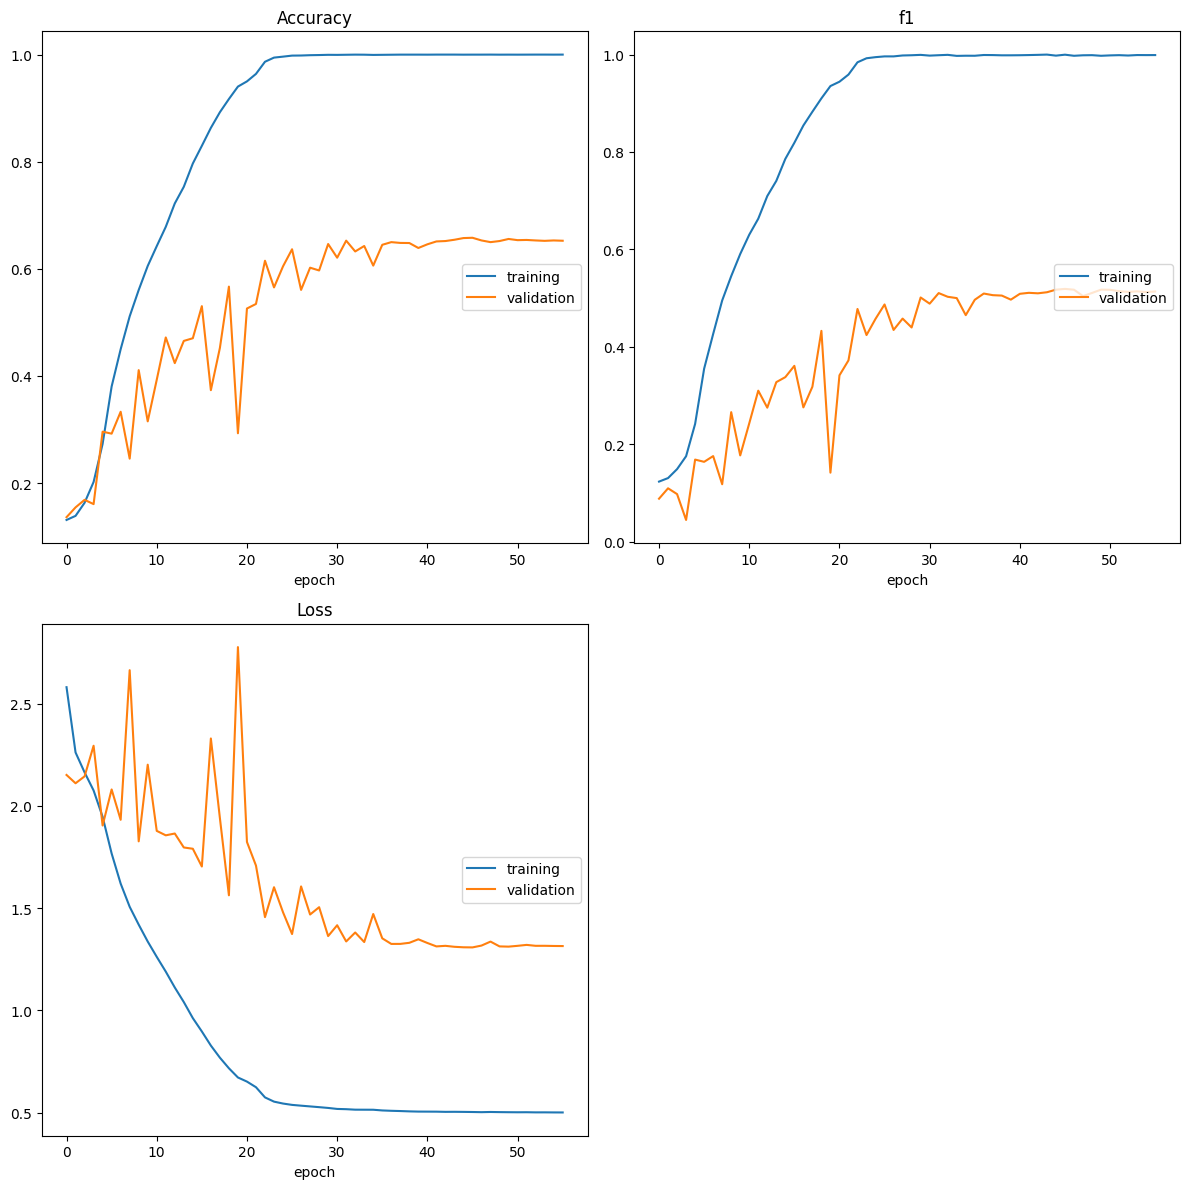

Accuracy
	training         	 (min:    0.131, max:    1.000, cur:    1.000)
	validation       	 (min:    0.136, max:    0.658, cur:    0.652)
f1
	training         	 (min:    0.123, max:    1.000, cur:    0.999)
	validation       	 (min:    0.045, max:    0.519, cur:    0.514)
Loss
	training         	 (min:    0.500, max:    2.580, cur:    0.500)
	validation       	 (min:    1.307, max:    2.776, cur:    1.314)
268/268 [==============================] - 20s 73ms/step - loss: 0.5005 - accuracy: 0.9999 - f1_score: 0.9990 - val_loss: 1.3141 - val_accuracy: 0.6524 - val_f1_score: 0.5136 - lr: 3.9063e-06
Epoch 56: early stopping


In [26]:

loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
opt = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(optimizer=opt, loss=loss,
              metrics=['accuracy', F1Score(num_classes=numero_clases, name='f1_score')])


callbacks = [
    EarlyStopping(
        monitor='val_f1_score',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_f1_score',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_f1_score',
        factor=0.5,
        patience=3,
        mode='max',
        verbose=1,
        min_lr=1e-6
    ),
    PlotLossesKeras(
        groups={
            'loss': ['loss', 'val_loss'],
            'acc': ['accuracy', 'val_accuracy'],
            'f1': ['f1_score', 'val_f1_score'],
        }
    )
]

model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=150,
    callbacks=callbacks,
    class_weight=class_weights
)

Resultados prometedores pero presenta claro sobreajuste el modelo. Veamos si mejora al aumentar el dropout de 0.4 a 0.5.

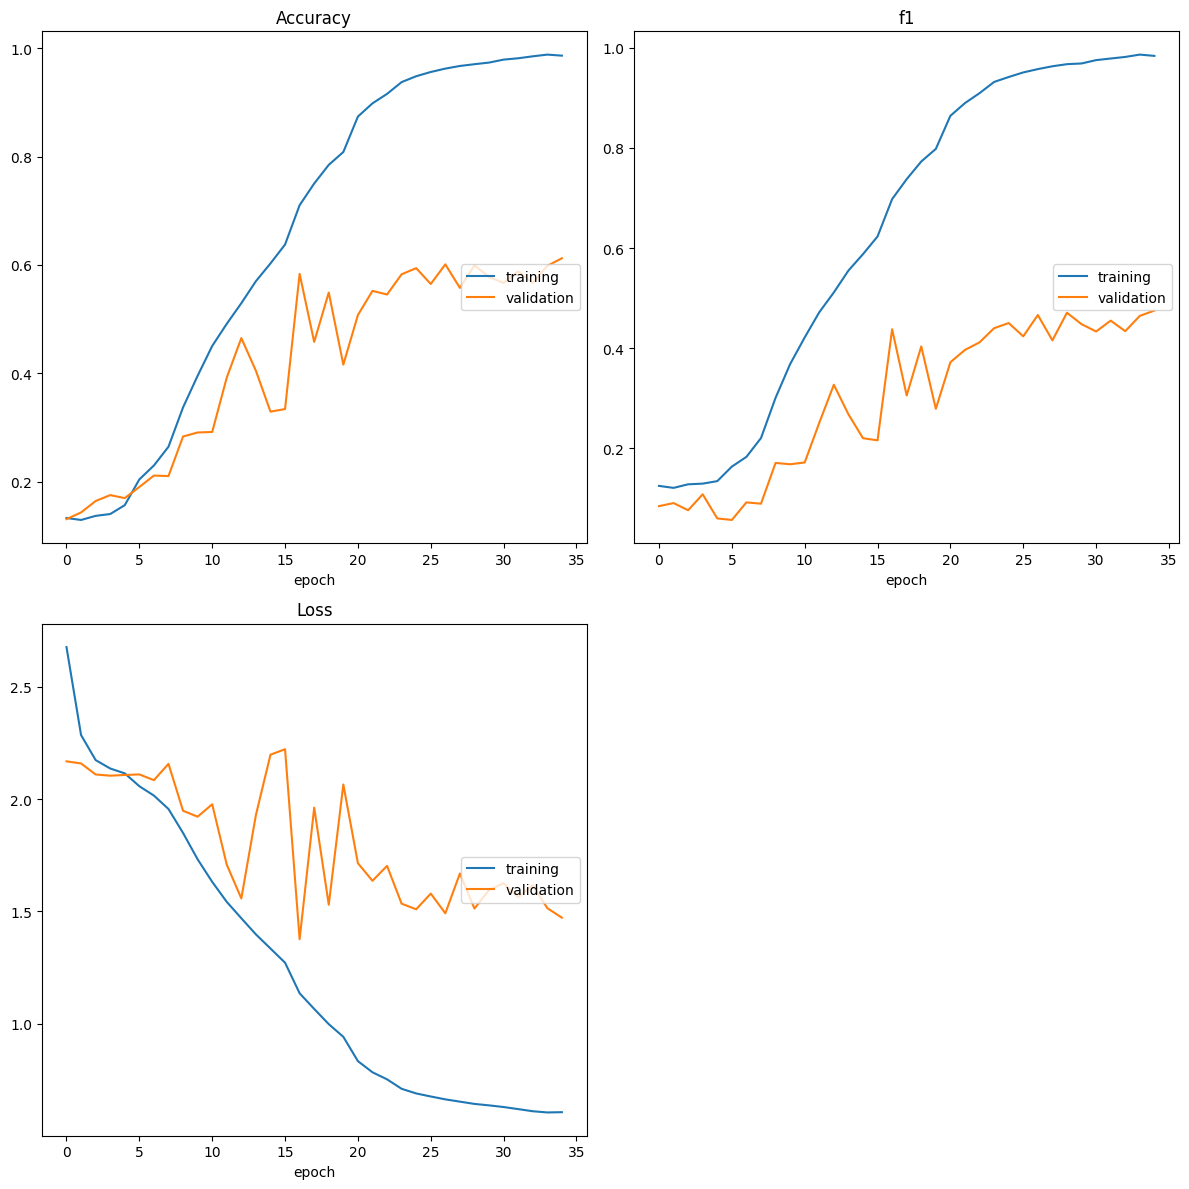

Accuracy
	training         	 (min:    0.129, max:    0.988, cur:    0.986)
	validation       	 (min:    0.131, max:    0.612, cur:    0.612)
f1
	training         	 (min:    0.121, max:    0.986, cur:    0.984)
	validation       	 (min:    0.057, max:    0.475, cur:    0.475)
Loss
	training         	 (min:    0.605, max:    2.677, cur:    0.606)
	validation       	 (min:    1.377, max:    2.223, cur:    1.472)
268/268 [==============================] - 20s 74ms/step - loss: 0.6061 - accuracy: 0.9863 - f1_score: 0.9838 - val_loss: 1.4724 - val_accuracy: 0.6123 - val_f1_score: 0.4753 - lr: 3.1250e-05
Epoch 36/150
 69/268 [======>.......................] - ETA: 11s - loss: 0.6074 - accuracy: 0.9869 - f1_score: 0.9837

KeyboardInterrupt: 

In [27]:
dropout = 0.5
l2_pen = 5e-5

inputs = tf.keras.Input(shape=(98, 98, 3))
x = conv_block(inputs, 32)
x = conv_block(x, 64)
x = conv_block(x, 128)
x = conv_block(x, 256)


# Clasificador:
# En vez de Flatten Global Average
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(dropout)(x)

x = Dense(256, activation='relu',
          kernel_initializer='he_normal',
          kernel_regularizer=tf.keras.regularizers.l2(l2_pen))(x)
x = BatchNormalization()(x)
x = Dropout(dropout)(x)

x = Dense(128, activation='relu',
          kernel_initializer='he_normal',
          kernel_regularizer=tf.keras.regularizers.l2(l2_pen))(x)
x = BatchNormalization()(x)
x = Dropout(dropout)(x)

outputs = Dense(numero_clases, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)




loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
opt = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(optimizer=opt, loss=loss,
              metrics=['accuracy', F1Score(num_classes=numero_clases, name='f1_score')])


callbacks = [
    EarlyStopping(
        monitor='val_f1_score',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_f1_score',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_f1_score',
        factor=0.5,
        patience=3,
        mode='max',
        verbose=1,
        min_lr=1e-6
    ),
    PlotLossesKeras(
        groups={
            'loss': ['loss', 'val_loss'],
            'acc': ['accuracy', 'val_accuracy'],
            'f1': ['f1_score', 'val_f1_score'],
        }
    )
]

model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=150,
    callbacks=callbacks,
    class_weight=class_weights
)

Vamos a construir un pequeño bucle para probar distintas combianciones de hiperparametros, para observar si hay alguna combinacion de 'dropout' y 'penalizacion L2' que mejore notariamente el F1-Score en validación.

In [ ]:

# Constructor del modelo en función de dropout y l2_pen
def build_model(dropout, l2_pen):
    inputs = Input(shape=(98, 98, 3))
    x = conv_block(inputs, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = conv_block(x, 256)

    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)

    x = Dense(
        256,
        activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(l2_pen)
    )(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)

    x = Dense(
        128,
        activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(l2_pen)
    )(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)

    outputs = Dense(numero_clases, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)

    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
    opt = tf.keras.optimizers.Adam(learning_rate=1e-3)

    model.compile(
        optimizer=opt,
        loss=loss,
        metrics=['accuracy', F1Score(num_classes=numero_clases, name='f1_score')]
    )
    return model

# Valores a explorar 
dropout_list = [0.3, 0.4, 0.45, 0.5, 0.55]
l2_list      = [3e-4, 1e-4, 8e-5, 5e-5, 2e-5]

mejor_f1 = -1.0
mejor_params = None
resultados = []

for d in dropout_list:
    for l2_pen in l2_list:
        print(f"\n=== Probando dropout={d}, l2_pen={l2_pen} ===")

        model = build_model(d, l2_pen)

        callbacks = [
            EarlyStopping(
                monitor='val_f1_score',
                patience=8,
                mode='max',
                restore_best_weights=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='val_f1_score',
                factor=0.5,
                patience=3,
                mode='max',
                min_lr=1e-6,
                verbose=1
            )
            # aquí NO pongo PlotLossesKeras para que sea más rápido
        ]

        history = model.fit(
            train_gen,
            validation_data=valid_gen,
            epochs=50,
            callbacks=callbacks,
            class_weight=class_weights,
            verbose=1
        )

        # Mejor F1 de validación para esta combinación
        val_f1_hist = history.history['val_f1_score']
        best_val_f1 = max(val_f1_hist)
        print(f"Mejor val_f1_score para (dropout={d}, l2={l2_pen}): {best_val_f1:.4f}")

        resultados.append((d, l2_pen, best_val_f1))

        if best_val_f1 > mejor_f1:
            mejor_f1 = best_val_f1
            mejor_params = (d, l2_pen)

print("\n==== RESULTADO FINAL ====")
print(f"Mejor combinación: dropout={mejor_params[0]}, l2_pen={mejor_params[1]}")
print(f"Mejor val_f1_score: {mejor_f1:.4f}")

print("\nTodas las combinaciones probadas:")
for d, l2_pen, f1 in resultados:
    print(f"  dropout={d}, l2_pen={l2_pen} -> val_f1_score_max={f1:.4f}")


=== Probando dropout=0.3, l2_pen=0.0003 ===
Epoch 1/50
155/155 [==============================] - 8s 43ms/step - loss: 2.7816 - accuracy: 0.1808 - f1_score: 0.1034 - val_loss: 2.1759 - val_accuracy: 0.3478 - val_f1_score: 0.0965 - lr: 0.0010
Epoch 2/50
155/155 [==============================] - 6s 40ms/step - loss: 2.3966 - accuracy: 0.2773 - f1_score: 0.1073 - val_loss: 3.1921 - val_accuracy: 0.2462 - val_f1_score: 0.0764 - lr: 0.0010
Epoch 3/50
155/155 [==============================] - 6s 39ms/step - loss: 2.3064 - accuracy: 0.3026 - f1_score: 0.1018 - val_loss: 2.1440 - val_accuracy: 0.3656 - val_f1_score: 0.0776 - lr: 0.0010
Epoch 4/50
154/155 [============================>.] - ETA: 0s - loss: 2.2480 - accuracy: 0.3205 - f1_score: 0.1001WARNING:tensorflow:Early stopping conditioned on metric `3` which is not available. Available metrics are: loss,accuracy,f1_score,val_loss,val_accuracy,val_f1_score

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
155/1

KeyboardInterrupt: 

In [95]:
print("\n==== RESULTADO FINAL ====")
print(f"Mejor combinación: dropout={mejor_params[0]}, l2_pen={mejor_params[1]}")
print(f"Mejor val_f1_score: {mejor_f1:.4f}")

print("\nTodas las combinaciones probadas:")
for d, l2_pen, f1 in resultados:
    print(f"  dropout={d}, l2_pen={l2_pen} -> val_f1_score_max={f1:.4f}")


==== RESULTADO FINAL ====
Mejor combinación: dropout=0.3, l2_pen=0.0001
Mejor val_f1_score: 0.3994

Todas las combinaciones probadas:
  dropout=0.3, l2_pen=0.0003 -> val_f1_score_max=0.3911
  dropout=0.3, l2_pen=0.0001 -> val_f1_score_max=0.3994
  dropout=0.3, l2_pen=8e-05 -> val_f1_score_max=0.3818
  dropout=0.3, l2_pen=5e-05 -> val_f1_score_max=0.3677
  dropout=0.3, l2_pen=2e-05 -> val_f1_score_max=0.3990
  dropout=0.4, l2_pen=0.0003 -> val_f1_score_max=0.3426
  dropout=0.4, l2_pen=0.0001 -> val_f1_score_max=0.3537
  dropout=0.4, l2_pen=8e-05 -> val_f1_score_max=0.3819
  dropout=0.4, l2_pen=5e-05 -> val_f1_score_max=0.3732
  dropout=0.4, l2_pen=2e-05 -> val_f1_score_max=0.3404
  dropout=0.45, l2_pen=0.0003 -> val_f1_score_max=0.3816
  dropout=0.45, l2_pen=0.0001 -> val_f1_score_max=0.3676
  dropout=0.45, l2_pen=8e-05 -> val_f1_score_max=0.3367
  dropout=0.45, l2_pen=5e-05 -> val_f1_score_max=0.0847
  dropout=0.45, l2_pen=2e-05 -> val_f1_score_max=0.3112
  dropout=0.5, l2_pen=0.0003 

Observamos que los resultados tampoco parecen ser tan prometedores ajustando los hiperparametros.

Vamos a reemplazar los bloques convolucionales por residuales. De manera que la información de entrada pueda fluir a distintas capas de la red y es más escalable.

### Modelo residual

Vamos a reemplazar los bloques convolucionales por residuales y aplicar los siguientes cambios:

* Sustituir bloques convolucionales por residuals blocks
* Reducir el tamaño de las capas densas
* Concatenar global max pooling y average pooling, para presentar activaciones promedio y máximas (información complementaria)

In [17]:
def residual_block(x, filters):
    shortcut = x
    x = Conv2D(filters, (3,3), padding='same',
               kernel_initializer='he_normal', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, (3,3), padding='same',
               kernel_initializer='he_normal', use_bias=False)(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1,1), padding='same',
                          kernel_initializer='he_normal', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    x = MaxPooling2D((2,2))(x)
    return x

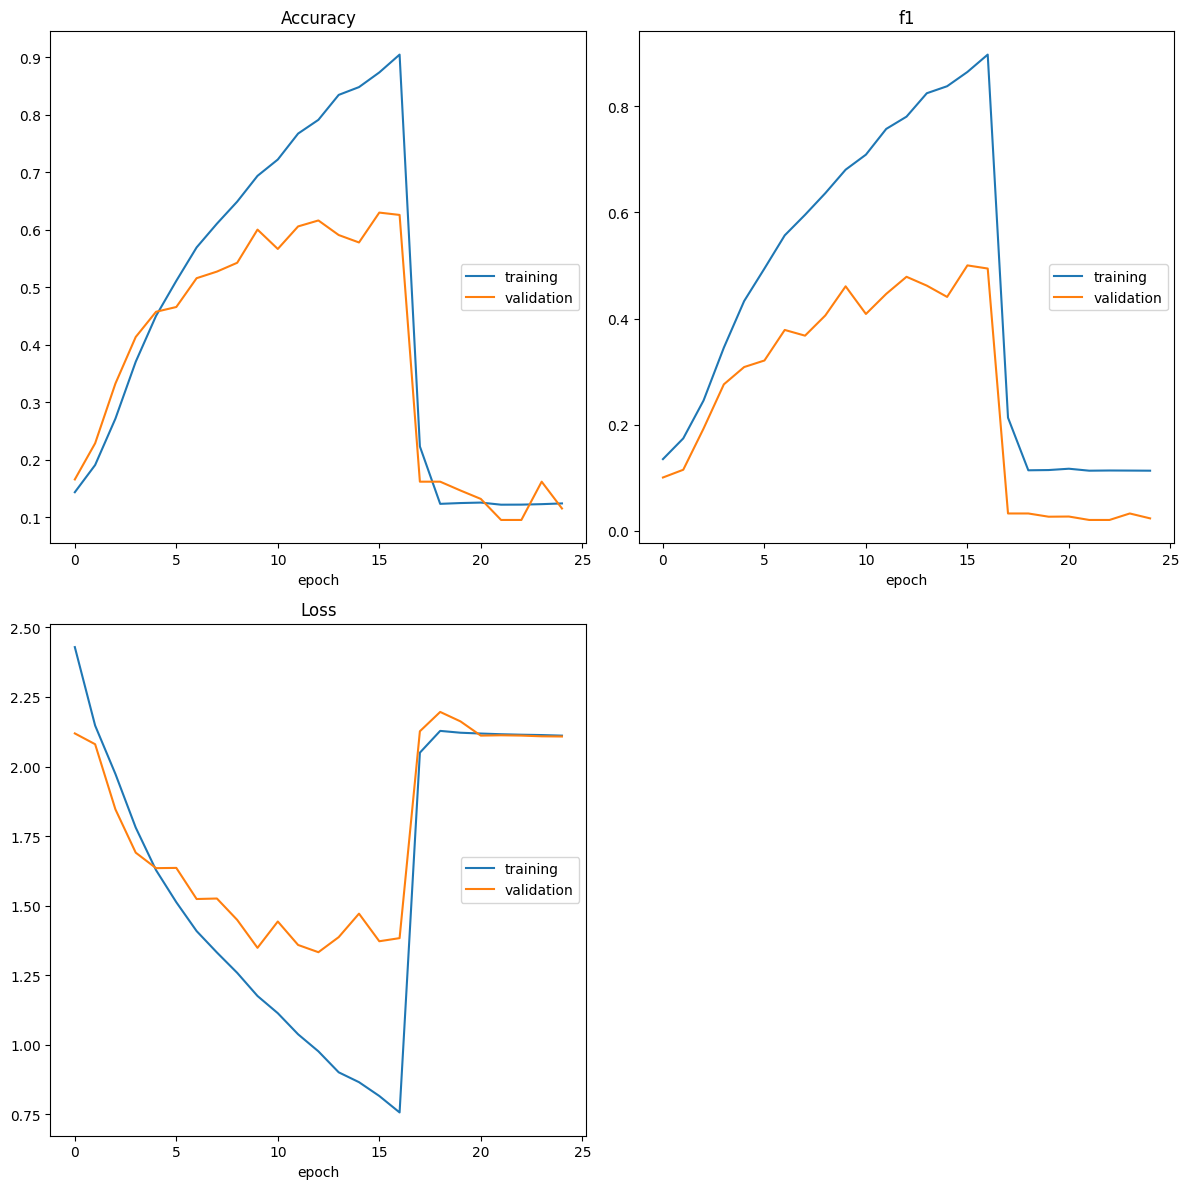

Accuracy
	training         	 (min:    0.122, max:    0.905, cur:    0.124)
	validation       	 (min:    0.095, max:    0.630, cur:    0.115)
f1
	training         	 (min:    0.114, max:    0.897, cur:    0.114)
	validation       	 (min:    0.021, max:    0.500, cur:    0.024)
Loss
	training         	 (min:    0.757, max:    2.429, cur:    2.111)
	validation       	 (min:    1.333, max:    2.196, cur:    2.108)
268/268 [==============================] - 22s 82ms/step - loss: 2.1111 - accuracy: 0.1239 - f1_score: 0.1135 - val_loss: 2.1080 - val_accuracy: 0.1151 - val_f1_score: 0.0238 - lr: 2.5000e-04
Epoch 26/150
268/268 [==============================] - ETA: 0s - loss: 2.1100 - accuracy: 0.1259 - f1_score: 0.1158

KeyboardInterrupt: 

In [29]:
dropout = 0.3
l2_pen = 1e-4

inputs = tf.keras.Input(shape=(98, 98, 3))
x = residual_block(inputs, 32)
x = residual_block(x, 64)
x = residual_block(x, 128)
x = residual_block(x, 256)


# Clasificador:
# En vez de Flatten Global Average
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = concatenate([gap, gmp])
x = BatchNormalization()(x)
x = Dropout(dropout)(x)

x = Dense(128, activation='relu',
          kernel_initializer='he_normal',
          kernel_regularizer=tf.keras.regularizers.l2(l2_pen))(x)
x = BatchNormalization()(x)
x = Dropout(dropout)(x)

x = Dense(64, activation='relu',
          kernel_initializer='he_normal',
          kernel_regularizer=tf.keras.regularizers.l2(l2_pen))(x)
x = BatchNormalization()(x)
x = Dropout(dropout)(x)

outputs = Dense(numero_clases, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)




loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
opt = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(optimizer=opt, loss=loss,
              metrics=['accuracy', F1Score(num_classes=numero_clases, name='f1_score')])



callbacks = [
    EarlyStopping(
        monitor='val_f1_score',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_f1_score',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_f1_score',
        factor=0.5,
        patience=3,
        mode='max',
        verbose=1,
        min_lr=1e-6
    ),
    PlotLossesKeras(
        groups={
            'loss': ['loss', 'val_loss'],
            'acc': ['accuracy', 'val_accuracy'],
            'f1': ['f1_score', 'val_f1_score'],
        }
    )
]

model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=150,
    callbacks=callbacks,
    class_weight=class_weights
)

Resulta que el modelo a colapsado (puede ser que algun peso haya superado el limite Nan y se vuelva 0). Vamos a aplicar clipnorm en el optimizador.

Resultados bastante prometedores para este modelo residual. Consiguiendo alcanzar 0.4 en F1-Score en pocas épocas.

Aunque seguimos presentando indicios de sobreajuste, volvamos a aumentar los hiperparametros.

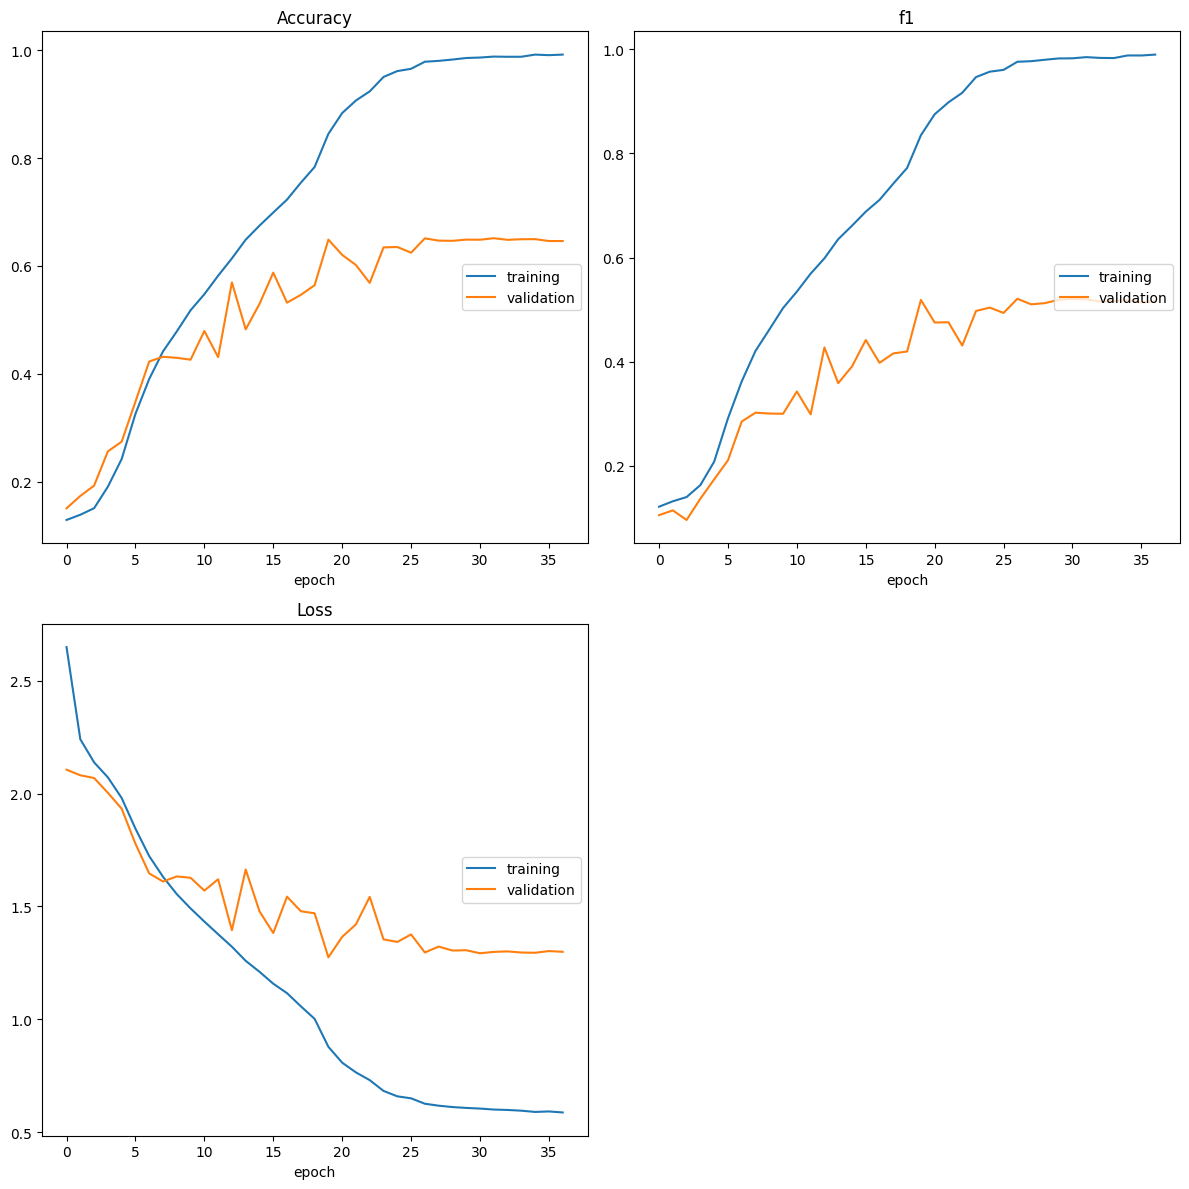

Accuracy
	training         	 (min:    0.129, max:    0.992, cur:    0.992)
	validation       	 (min:    0.150, max:    0.651, cur:    0.646)
f1
	training         	 (min:    0.121, max:    0.990, cur:    0.990)
	validation       	 (min:    0.096, max:    0.521, cur:    0.516)
Loss
	training         	 (min:    0.587, max:    2.649, cur:    0.587)
	validation       	 (min:    1.275, max:    2.106, cur:    1.299)
268/268 [==============================] - 22s 83ms/step - loss: 0.5872 - accuracy: 0.9919 - f1_score: 0.9901 - val_loss: 1.2988 - val_accuracy: 0.6461 - val_f1_score: 0.5158 - lr: 1.5625e-05
Epoch 37: early stopping


In [21]:

dropout = 0.5
l2_pen = 5e-5

inputs = tf.keras.Input(shape=(98, 98, 3))
x = residual_block(inputs, 32)
x = residual_block(x, 64)
x = residual_block(x, 128)
x = residual_block(x, 256)


# Clasificador:
# En vez de Flatten Global Average
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = concatenate([gap, gmp])
x = BatchNormalization()(x)
x = Dropout(dropout)(x)

x = Dense(128, activation='relu',
          kernel_initializer='he_normal',
          kernel_regularizer=tf.keras.regularizers.l2(l2_pen))(x)
x = BatchNormalization()(x)
x = Dropout(dropout)(x)

x = Dense(64, activation='relu',
          kernel_initializer='he_normal',
          kernel_regularizer=tf.keras.regularizers.l2(l2_pen))(x)
x = BatchNormalization()(x)
x = Dropout(dropout)(x)

outputs = Dense(numero_clases, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)




loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
opt = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(optimizer=opt, loss=loss,
              metrics=['accuracy', F1Score(num_classes=numero_clases, name='f1_score')])


callbacks = [
    EarlyStopping(
        monitor='val_f1_score',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model_drp05.keras',
        monitor='val_f1_score',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_f1_score',
        factor=0.5,
        patience=3,
        mode='max',
        verbose=1,
        min_lr=1e-6
    ),
    PlotLossesKeras(
        groups={
            'loss': ['loss', 'val_loss'],
            'acc': ['accuracy', 'val_accuracy'],
            'f1': ['f1_score', 'val_f1_score'],
        }
    )
]

model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=150,
    callbacks=callbacks,
    class_weight=class_weights
)

Observamos que sigue obteniendo valores altos de F1-Score para training pero no tanto para validación. Analicemos con más detalles el rendimiento para cada clase, vamos a usar classification_report:
* Precisión: de las veces que el modelo precide cada clase, cuantas veces acierta. Baja precisión, se confunde de clase.
* Recall: de las veces que la instancia era de la clase X, cuantas veces acierta. Bajo recall, no reconoce la clase.
* F1-Score: Es $\frac{2 P R}{P + R}$. La cual queremos que sea la más alta posible (tendremos que obtener buenos valores de Precisión y Recall).

In [22]:

from sklearn.metrics import f1_score, classification_report, confusion_matrix

# 1. Obtener predicciones y etiquetas verdaderas en todo valid_gen
y_true_all = []
y_pred_all = []

for X_batch, y_batch in valid_gen:
    # Etiquetas verdaderas como índices
    y_true_all.extend(np.argmax(y_batch, axis=1))

    # Predicciones del modelo
    y_pred_proba = model.predict(X_batch, verbose=0)
    y_pred_all.extend(np.argmax(y_pred_proba, axis=1))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# 2. F1-score global (macro, micro, weighted)
print("F1 macro:",     f1_score(y_true_all, y_pred_all, average='macro'))
print("F1 weighted:",  f1_score(y_true_all, y_pred_all, average='weighted'))

# 3. Informe por clase (precisión, recall, F1)
print("\nClasification report por clase:")
print(classification_report(y_true_all, y_pred_all, target_names=clases_img))

# 4. Accuracy por clase usando la matriz de confusión
cm = confusion_matrix(y_true_all, y_pred_all)
aciertos_por_clase = np.diag(cm)
total_por_clase = cm.sum(axis=1)
acc_por_clase = aciertos_por_clase / total_por_clase

print("\nAccuracy por clase:")
for i, acc in enumerate(acc_por_clase):
    print(f"{clases_img[i]}: {acc:.3f}")

F1 macro: 0.6443315172032682
F1 weighted: 0.6524483280851757

Clasification report por clase:
              precision    recall  f1-score   support

       Anger       0.63      0.66      0.64       712
    Contempt       0.63      0.70      0.66       618
     Disgust       0.62      0.60      0.61       672
        Fear       0.70      0.63      0.67       622
       Happy       0.84      0.82      0.83       791
     Neutral       0.51      0.58      0.54       514
         Sad       0.54      0.57      0.55       603
    Surprise       0.69      0.62      0.65       874

    accuracy                           0.65      5406
   macro avg       0.65      0.65      0.64      5406
weighted avg       0.66      0.65      0.65      5406


Accuracy por clase:
Anger: 0.656
Contempt: 0.697
Disgust: 0.600
Fear: 0.633
Happy: 0.818
Neutral: 0.576
Sad: 0.569
Surprise: 0.617


In [23]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# 1. Obtener predicciones y etiquetas verdaderas en todo valid_gen
y_true_all = []
y_pred_all = []

for X_batch, y_batch in train_gen:
    # Etiquetas verdaderas como índices
    y_true_all.extend(np.argmax(y_batch, axis=1))

    # Predicciones del modelo
    y_pred_proba = model.predict(X_batch, verbose=0)
    y_pred_all.extend(np.argmax(y_pred_proba, axis=1))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# 2. F1-score global (macro, micro, weighted)
print("F1 macro:",     f1_score(y_true_all, y_pred_all, average='macro'))
print("F1 weighted:",  f1_score(y_true_all, y_pred_all, average='weighted'))

# 3. Informe por clase (precisión, recall, F1)
print("\nClasification report por clase:")
print(classification_report(y_true_all, y_pred_all, target_names=clases_img))

# 4. Accuracy por clase usando la matriz de confusión
cm = confusion_matrix(y_true_all, y_pred_all)
aciertos_por_clase = np.diag(cm)
total_por_clase = cm.sum(axis=1)
acc_por_clase = aciertos_por_clase / total_por_clase

print("\nAccuracy por clase:")
for i, acc in enumerate(acc_por_clase):
    print(f"{clases_img[i]}: {acc:.3f}")

F1 macro: 0.999283379913551
F1 weighted: 0.9992982855272272

Clasification report por clase:
              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00      2339
    Contempt       1.00      1.00      1.00      1996
     Disgust       1.00      1.00      1.00      2242
        Fear       1.00      1.00      1.00      2021
       Happy       1.00      1.00      1.00      2154
     Neutral       1.00      1.00      1.00      1616
         Sad       1.00      1.00      1.00      1914
    Surprise       1.00      1.00      1.00      2819

    accuracy                           1.00     17101
   macro avg       1.00      1.00      1.00     17101
weighted avg       1.00      1.00      1.00     17101


Accuracy por clase:
Anger: 0.998
Contempt: 0.999
Disgust: 1.000
Fear: 0.999
Happy: 1.000
Neutral: 1.000
Sad: 0.999
Surprise: 1.000


Como era de esperar. En training presenta mejor rendimiento.

Además se observa un desbalanceo entre clases, le resulta más facil al modelo predecir 'Felicidad' que 'Neutral', en parte podría deberse por el desbalanceo en el conjunto de datos.

Para tratar de evitar el sobreajuste, vamos a reducir la capacidad de modelo. De manera que trate de generalizar mejor los datos y obtener mejores resultados.

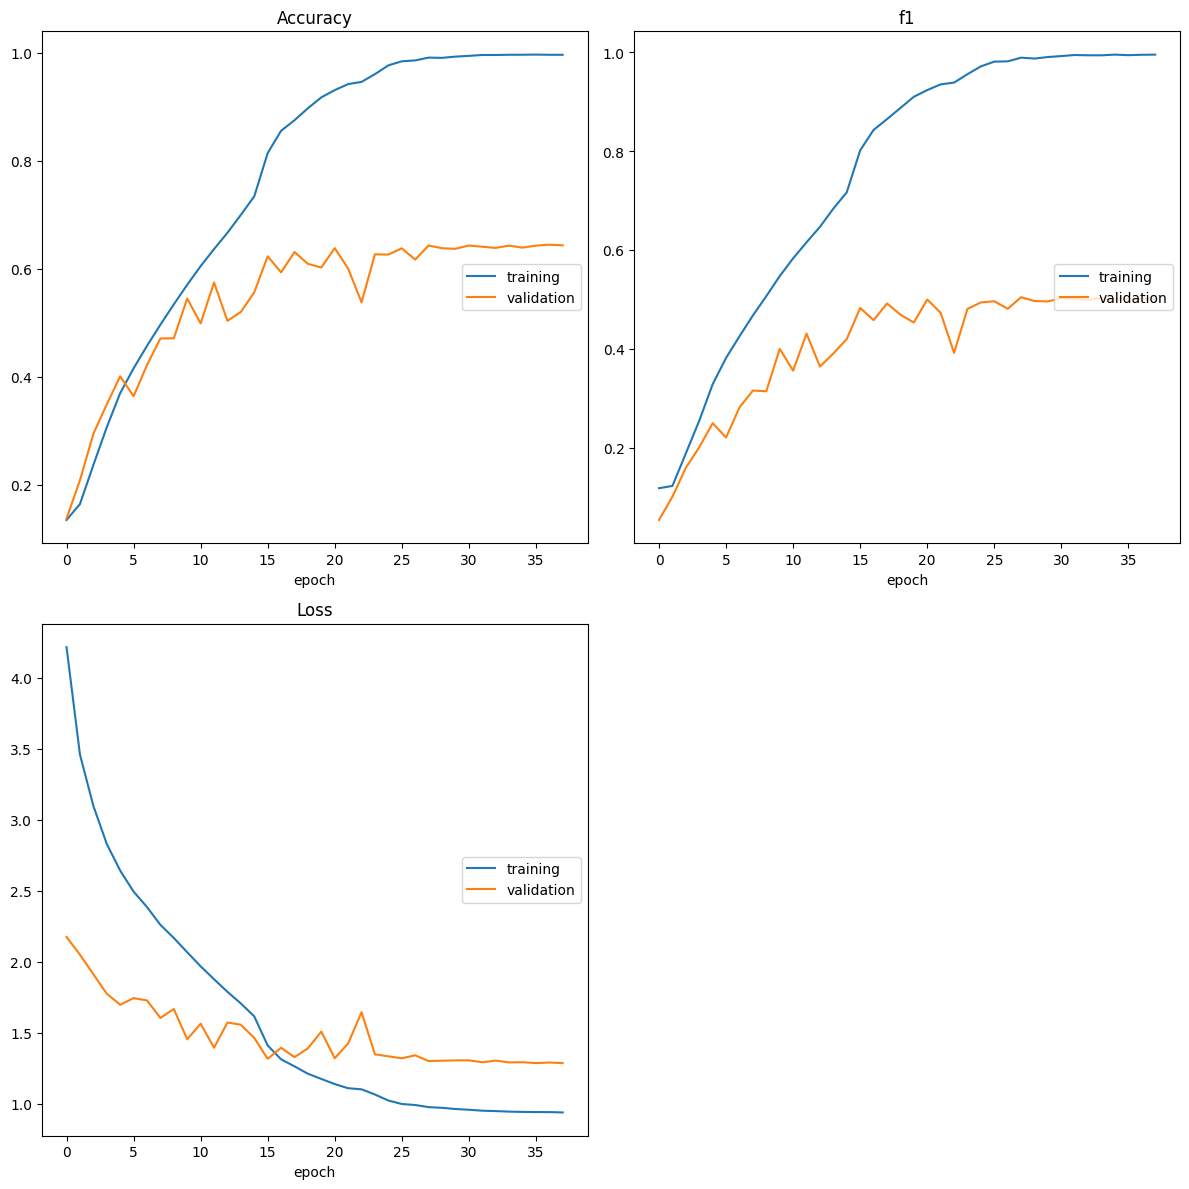

Accuracy
	training         	 (min:    0.134, max:    0.997, cur:    0.996)
	validation       	 (min:    0.137, max:    0.644, cur:    0.643)
f1
	training         	 (min:    0.118, max:    0.995, cur:    0.995)
	validation       	 (min:    0.053, max:    0.504, cur:    0.501)
Loss
	training         	 (min:    0.940, max:    4.215, cur:    0.940)
	validation       	 (min:    1.288, max:    2.175, cur:    1.288)
268/268 [==============================] - 23s 85ms/step - loss: 0.9405 - accuracy: 0.9964 - f1_score: 0.9954 - val_loss: 1.2877 - val_accuracy: 0.6434 - val_f1_score: 0.5011 - lr: 1.5625e-05
Epoch 38: early stopping


In [90]:

dropout = 0.5
l2_pen = 1e-4

inputs = tf.keras.Input(shape=(98, 98, 3))
x = residual_block(inputs, 32)
x = residual_block(x, 64)
x = residual_block(x, 128)
x = residual_block(x, 256)


# Clasificador:
# En vez de Flatten Global Average
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = concatenate([gap, gmp])
x = BatchNormalization()(x)
x = Dropout(dropout)(x)

# x = Dense(128, activation='relu',
#           kernel_initializer='he_normal',
#           kernel_regularizer=tf.keras.regularizers.l2(l2_pen))(x)
# x = BatchNormalization()(x)
# x = Dropout(dropout)(x)

x = Dense(64, activation='relu',
          kernel_initializer='he_normal',
          kernel_regularizer=tf.keras.regularizers.l2(l2_pen))(x)
x = BatchNormalization()(x)
x = Dropout(dropout)(x)

outputs = Dense(numero_clases, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)




loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
opt = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(optimizer=opt, loss=loss,
              metrics=['accuracy', F1Score(num_classes=numero_clases, name='f1_score')])


callbacks = [
    EarlyStopping(
        monitor='val_f1_score',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model_v3.keras',
        monitor='val_f1_score',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_f1_score',
        factor=0.5,
        patience=3,
        mode='max',
        verbose=1,
        min_lr=1e-6
    ),
    PlotLossesKeras(
        groups={
            'loss': ['loss', 'val_loss'],
            'acc': ['accuracy', 'val_accuracy'],
            'f1': ['f1_score', 'val_f1_score'],
        }
    )
]

model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=150,
    callbacks=callbacks,
    class_weight=class_weights
)

Analicemos el rendimiento obtenido del nuevo modelo menos expresivo.

In [91]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# 1. Obtener predicciones y etiquetas verdaderas en todo valid_gen
y_true_all = []
y_pred_all = []

for X_batch, y_batch in valid_gen:
    # Etiquetas verdaderas como índices
    y_true_all.extend(np.argmax(y_batch, axis=1))

    # Predicciones del modelo
    y_pred_proba = model.predict(X_batch, verbose=0)
    y_pred_all.extend(np.argmax(y_pred_proba, axis=1))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# 2. F1-score global (macro, micro, weighted)
print("F1 macro:",     f1_score(y_true_all, y_pred_all, average='macro'))
print("F1 weighted:",  f1_score(y_true_all, y_pred_all, average='weighted'))

# 3. Informe por clase (precisión, recall, F1)
print("\nClasification report por clase:")
print(classification_report(y_true_all, y_pred_all, target_names=clases_img))

# 4. Accuracy por clase usando la matriz de confusión
cm = confusion_matrix(y_true_all, y_pred_all)
aciertos_por_clase = np.diag(cm)
total_por_clase = cm.sum(axis=1)
acc_por_clase = aciertos_por_clase / total_por_clase

print("\nAccuracy por clase:")
for i, acc in enumerate(acc_por_clase):
    print(f"{clases_img[i]}: {acc:.3f}")

F1 macro: 0.638319626904156
F1 weighted: 0.6459321302755435

Clasification report por clase:
              precision    recall  f1-score   support

       Anger       0.61      0.64      0.63       712
    Contempt       0.67      0.65      0.66       618
     Disgust       0.62      0.56      0.59       672
        Fear       0.65      0.69      0.67       622
       Happy       0.86      0.78      0.82       791
     Neutral       0.50      0.63      0.55       514
         Sad       0.51      0.57      0.54       603
    Surprise       0.71      0.60      0.65       874

    accuracy                           0.64      5406
   macro avg       0.64      0.64      0.64      5406
weighted avg       0.65      0.64      0.65      5406


Accuracy por clase:
Anger: 0.645
Contempt: 0.646
Disgust: 0.562
Fear: 0.693
Happy: 0.779
Neutral: 0.628
Sad: 0.572
Surprise: 0.601


In [92]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# 1. Obtener predicciones y etiquetas verdaderas en todo valid_gen
y_true_all = []
y_pred_all = []

for X_batch, y_batch in train_gen:
    # Etiquetas verdaderas como índices
    y_true_all.extend(np.argmax(y_batch, axis=1))

    # Predicciones del modelo
    y_pred_proba = model.predict(X_batch, verbose=0)
    y_pred_all.extend(np.argmax(y_pred_proba, axis=1))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# 2. F1-score global (macro, micro, weighted)
print("F1 macro:",     f1_score(y_true_all, y_pred_all, average='macro'))
print("F1 weighted:",  f1_score(y_true_all, y_pred_all, average='weighted'))

# 3. Informe por clase (precisión, recall, F1)
print("\nClasification report por clase:")
print(classification_report(y_true_all, y_pred_all, target_names=clases_img))

# 4. Accuracy por clase usando la matriz de confusión
cm = confusion_matrix(y_true_all, y_pred_all)
aciertos_por_clase = np.diag(cm)
total_por_clase = cm.sum(axis=1)
acc_por_clase = aciertos_por_clase / total_por_clase

print("\nAccuracy por clase:")
for i, acc in enumerate(acc_por_clase):
    print(f"{clases_img[i]}: {acc:.3f}")

F1 macro: 0.9998408793559099
F1 weighted: 0.999824546617674

Clasification report por clase:
              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00      2339
    Contempt       1.00      1.00      1.00      1996
     Disgust       1.00      1.00      1.00      2242
        Fear       1.00      1.00      1.00      2021
       Happy       1.00      1.00      1.00      2154
     Neutral       1.00      1.00      1.00      1616
         Sad       1.00      1.00      1.00      1914
    Surprise       1.00      1.00      1.00      2819

    accuracy                           1.00     17101
   macro avg       1.00      1.00      1.00     17101
weighted avg       1.00      1.00      1.00     17101


Accuracy por clase:
Anger: 1.000
Contempt: 1.000
Disgust: 1.000
Fear: 1.000
Happy: 1.000
Neutral: 1.000
Sad: 1.000
Surprise: 0.999


Observamos que conseguimos F1-Score de 64% para validación, que es ligeramente peor que el modelo anterior aunque con menos parametros (hemos quitado una capa densa).

Aun tendríamos margen de mejora, ya que observamos un rendimiento del 100% para entrenamiento. Lo cual sugiere que el modelo sigue sobreajustando demasiado el conjunto de entrenamiento.

He tratado de reducir la expresividad del modelo con otras arquitecturas sin éxito alguno (no mejora el F1-Score en validación). También he probado a descargar un modelo ya entrenado de ResNet y aplicarlo al dataset, pero no he logrado obtener buenos resultados asi que he optado por dejar el estudio aqu. Logrando el 60% en validación para F1-Score que parece ser un valor aceptable.

##  Preparación del archivo de soluciones

Prepara el archivo para hacer la entrenga (submission) en la competición Kaggle (https://www.kaggle.com/t/8907c7fbe929457fade9646f0eb7c81d).

La siguiente celda descarga la plantilla del archivo de entrega a la competición y establecer la columna *Target* a *None*.

In [24]:
url = "https://hdvirtual.us.es/discovirt/public.php/dav/files/LfcQDfgNFn3sdrx/"
urllib.request.urlretrieve(url, "solution_template.csv")
sol_template = pd.read_csv('solution_template.csv')
sol_template['Target'] = None

Genera ahora las predicción para las imágenes del test y asigna en la fila correspondiente, según el nombre del archivo de imagen, la predicción obtenida por tu modelo.

In [25]:
class FacialExpressionSequenceTest(tf.keras.utils.Sequence):

    def __init__(self, img_dir, class_names, batch_size=32, img_size=(98, 98)):
        self.img_dir     = img_dir
        self.class_names = class_names
        self.batch_size  = batch_size
        self.img_size    = img_size

        # Orden fijo y reproducible — NUNCA barajar en test
        self.imagenes = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

    def __len__(self):
        return int(np.ceil(len(self.imagenes) / self.batch_size))

    def __getitem__(self, idx):
        batch_files = self.imagenes[idx * self.batch_size : (idx + 1) * self.batch_size]
        X = []
        for fname in batch_files:
            img = Image.open(os.path.join(self.img_dir, fname)).resize(self.img_size)
            X.append(np.array(img) / 255.0)
        return np.array(X)

In [26]:
test_gen = FacialExpressionSequenceTest(
    img_dir     = os.path.join(dataset_dir, "test", "images"),
    class_names = clases_img,
    batch_size  = 32,
    img_size    = (98, 98)
)

y_pred_probs = model.predict(test_gen, verbose=1)
y_pred_idx   = np.argmax(y_pred_probs, axis=1)

# IDs EXACTAMENTE como en el CSV: con extensión
fnames = test_gen.imagenes          # p.ej. 'image0028975.jpg'
ids    = fnames                     # ya llevan extensión

urllib.request.urlretrieve(url, "solution_template.csv")
sol_template = pd.read_csv('solution_template.csv')

print(sol_template.head())
print(sol_template.columns)

# Asegúrate de que la columna se llama exactamente 'ID'
pred_dict = dict(zip(ids, y_pred_idx))
sol_template['Target'] = sol_template['ID'].map(pred_dict)

print(sol_template.head(10))
print(f"Filas rellenadas: {sol_template['Target'].notna().sum()} / {len(sol_template)}")
sol_template.to_csv('submission.csv', index=False)

55/55 [==============================] - 10s 177ms/step
                 ID
0  image0028975.jpg
1      ffhq_359.png
2  image0029090.jpg
3  image0027209.jpg
4  image0041497.jpg
Index(['ID'], dtype='object')
                 ID  Target
0  image0028975.jpg       0
1      ffhq_359.png       7
2  image0029090.jpg       6
3  image0027209.jpg       0
4  image0041497.jpg       6
5     ffhq_2224.png       2
6  image0023687.jpg       7
7  image0022722.jpg       6
8      ffhq_102.png       4
9  image0030719.jpg       0
Filas rellenadas: 1760 / 1760


Por último, se guarda el arhivo de entrega. Descargalo y has la entrega en la copetición de Kaggle.

In [27]:
sol_template.to_csv('subm.csv', index=False)
sol_template

,ID,Target
0,image0028975.jpg,0
1,ffhq_359.png,7
2,image0029090.jpg,6
3,image0027209.jpg,0
4,image0041497.jpg,6
...,...,...
1755,ffhq_1774.png,0
1756,ffhq_4596.png,4
1757,image0014501.jpg,3
1758,image0026320.jpg,2


In [28]:
import os

print(os.getcwd())          # ruta de la carpeta actual
print(os.listdir(os.getcwd()))  # lista de archivos; deberías ver 'subm.csv'

c:\Users\encis\Documents\US\Asignaturas\AP\Tarea4
['best_model.keras', 'best_model_aug.keras', 'best_model_drp05.keras', 'best_model_internet.weights.h5', 'best_model_internet_stage1.keras', 'best_model_v3.keras', 'best_model_v4.keras', 'best_model_v5.keras', 'best_model_v6.keras', 'mejor_modelo.keras', 'mejor_modelo_aug_v1.keras', 'mejor_modelo_jpg_png.keras', 'Reconocimiento_de_expresiones_faciales - copia.ipynb', 'Reconocimiento_de_expresiones_faciales.ipynb', 'solution_template.csv', 'subm.csv', 'submission.csv', 'untitled_project']


Trabajo realizado por Manuel Enciso Martínez

---